# VGGT Streaming Variants Comparison

**Goal:** Benchmark 5 VGGT variants on latency, peak GPU memory, and output shape consistency
to select the optimal encoder backbone for the thesis pipeline (world model + 3D scene understanding).

**Variants:**

| # | Variant | Key Feature | Repo |
|---|---------|-------------|------|
| 1 | VGGT (baseline) | Full 1B model, batch forward | `facebook/VGGT-1B` |
| 2 | StreamVGGT | Temporal streaming with KV cache | `lch01/StreamVGGT` |
| 3 | SceneVGGT | SLAM integration, scene modules | Same weights as VGGT |
| 4 | InfiniteVGGT | Token budget for long sequences | StreamVGGT weights |
| 5 | FastVGGT | Token merging for speed | `facebook/VGGT_tracker_fixed` |

**Acceptance criteria:** latency measurements for N=10,20,50,100,500 frames, peak GPU memory,
output shape consistency, summary DataFrame, visualization plots.

**Kernel:** uv-managed Python 3.12 env (`uv run jupyter lab`)

---
## Table of Contents
1. [Setup & Imports](#1)
2. [Collect / Generate Observations](#2)
3. [Model Loading Functions](#3)
4. [Benchmark Function](#4)
5. [Per-Variant Inference Wrappers](#5)
6. [Run Benchmarks](#6)
7. [Results DataFrame](#7)
8. [Latency Plot](#8)
9. [Memory Plot](#9)
10. [Combined Summary Bar Chart](#10)
11. [Output Shape Consistency](#11)
12. [Summary & Recommendation](#12)
13. [DreamerV3 Integration Benchmark](#13)
14. [world_points vs pts3d_in_other_view Visualization](#14)

---
## 1. Setup & Imports <a id='1'></a>

In [1]:
import sys
import os
import gc
import time
import importlib
from pathlib import Path

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path(os.path.abspath(".."))
EXTERNAL = REPO_ROOT / "external"

# Device detection
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# Precision: bfloat16 if compute capability >= 8 (Ampere+), else float16
if device.type == "cuda":
    cc = torch.cuda.get_device_capability()
    dtype = torch.bfloat16 if cc[0] >= 8 else torch.float16
else:
    dtype = torch.float32

print(f"torch: {torch.__version__}")
print(f"device: {device}")
print(f"dtype: {dtype}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name()}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

torch: 2.10.0+cu128
device: cuda
dtype: torch.bfloat16
GPU: NVIDIA H100
VRAM: 100.0 GB


In [2]:
# GPU memory helpers
def reset_memory_stats():
    """Reset CUDA peak memory tracking."""
    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.empty_cache()

def get_peak_memory_mb() -> float:
    """Return peak GPU memory allocated in MB since last reset."""
    if device.type == "cuda":
        return torch.cuda.max_memory_allocated() / 1e6
    return 0.0

def unload_model(model):
    """Delete model and free GPU memory."""
    del model
    gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()

---
## 2. Collect / Generate Observations <a id='2'></a>

Try to load Habitat observations; fall back to synthetic random tensors if `habitat_sim` is unavailable.

In [3]:
SEQ_LENGTHS = [10, 20, 50, 100, 500]
IMG_H, IMG_W = 518, 518  # VGGT default input size
MAX_N = max(SEQ_LENGTHS)

USE_HABITAT = False
try:
    import habitat_sim
    USE_HABITAT = True
except ImportError:
    pass

if USE_HABITAT:
    print("habitat_sim available — collecting real observations")
    scene_dataset = REPO_ROOT / "data" / "scene_datasets" / "hm3d" / "minival"
    scene_paths = sorted(scene_dataset.rglob("*.glb"))
    if not scene_paths:
        print(f"WARNING: No .glb scenes in {scene_dataset}, falling back to synthetic")
        USE_HABITAT = False

if USE_HABITAT:
    # Collect RGB frames from first HM3D scene with random actions
    sim_cfg = habitat_sim.SimulatorConfiguration()
    sim_cfg.scene_id = str(scene_paths[0])
    sim_cfg.enable_physics = False

    rgb_cfg = habitat_sim.CameraSensorSpec()
    rgb_cfg.uuid = "rgb"
    rgb_cfg.sensor_type = habitat_sim.SensorType.COLOR
    rgb_cfg.resolution = [IMG_H, IMG_W]
    rgb_cfg.position = [0.0, 1.5, 0.0]

    agent_cfg = habitat_sim.agent.AgentConfiguration(sensor_specifications=[rgb_cfg])
    sim = habitat_sim.Simulator(habitat_sim.Configuration(sim_cfg, [agent_cfg]))

    # Use only actions in default action space
    import random
    action_names = ["move_forward", "turn_left", "turn_right"]
    frames = []
    sim.reset()
    for _ in range(MAX_N):
        obs = sim.get_sensor_observations()
        rgb = obs["rgb"][:, :, :3]  # drop alpha, [H, W, 3] uint8
        # Convert to [3, H, W] float32 [0, 1]
        frame = torch.from_numpy(rgb).permute(2, 0, 1).float() / 255.0
        frames.append(frame)
        sim.step(random.choice(action_names))
    sim.close()

    all_images = torch.stack(frames)  # [MAX_N, 3, H, W]
    print(f"Collected {len(frames)} Habitat frames: {all_images.shape}")
else:
    print("WARNING: habitat_sim not available — using synthetic random tensors")
    print("Results will NOT reflect real-world performance characteristics.")
    rng = np.random.default_rng(42)
    all_images = torch.from_numpy(
        rng.random((MAX_N, 3, IMG_H, IMG_W), dtype=np.float32)
    )
    print(f"Generated synthetic frames: {all_images.shape}")

print(f"Value range: [{all_images.min():.3f}, {all_images.max():.3f}]")
print(f"dtype: {all_images.dtype}")

/pfs/data6/home/ul/ul_student/ul_hfj15/Master-Thesis-3D-VLA/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


habitat_sim available — collecting real observations


[09:21:27:622895]:[Warning]:[Metadata] SceneDatasetAttributes.cpp(107)::addNewSceneInstanceToDataset : Dataset : 'default' : Lighting Layout Attributes 'no_lights' specified in Scene Attributes but does not exist in dataset, so creating default.
[09:21:27:630701]:[Warning]:[Scene] SemanticScene.h(331)::checkFileExists : ::loadSemanticSceneDescriptor: File `/pfs/data6/home/ul/ul_student/ul_hfj15/Master-Thesis-3D-VLA/data/scene_datasets/hm3d/minival/00800-TEEsavR23oF/TEEsavR23oF.basis.scn` does not exist.  Aborting load.
[09:21:27:631208]:[Warning]:[Scene] SemanticScene.cpp(124)::loadSemanticSceneDescriptor : SSD File Naming Issue! Neither SemanticAttributes-provided name : `/pfs/data6/home/ul/ul_student/ul_hfj15/Master-Thesis-3D-VLA/data/scene_datasets/hm3d/minival/00800-TEEsavR23oF/TEEsavR23oF.basis.scn` nor constructed filename : `/pfs/data6/home/ul/ul_student/ul_hfj15/Master-Thesis-3D-VLA/data/scene_datasets/hm3d/minival/00800-TEEsavR23oF/info_semantic.json` exist on disk.
[09:21:27:

Renderer: NVIDIA H100/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 570.195.03
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-broken-buffer-dsa
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-framebuffer-invalidation-wants-draw-binding
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-

Collected 500 Habitat frames: torch.Size([500, 3, 518, 518])
Value range: [0.000, 1.000]
dtype: torch.float32


---
## 3. Model Loading Functions <a id='3'></a>

Each variant has its own loader. Since VGGT/SceneVGGT/FastVGGT share the `vggt` module name,
we swap `sys.path` entries and use `importlib` to avoid import collisions.

In [4]:
def _clean_sys_path():
    """Remove all external/* entries from sys.path to avoid import collisions."""
    ext_str = str(EXTERNAL)
    sys.path[:] = [p for p in sys.path if not p.startswith(ext_str)]
    # Also remove cached vggt/streamvggt modules
    for mod_name in list(sys.modules.keys()):
        if mod_name.startswith("vggt") or mod_name.startswith("streamvggt"):
            del sys.modules[mod_name]


def load_vggt_baseline():
    """Load VGGT baseline (facebook/VGGT-1B)."""
    _clean_sys_path()
    sys.path.insert(0, str(EXTERNAL / "VGGT"))
    from vggt.models.vggt import VGGT
    model = VGGT.from_pretrained("facebook/VGGT-1B")
    model = model.to(device).eval()
    return model


def load_streamvggt():
    """Load StreamVGGT (lch01/StreamVGGT)."""
    _clean_sys_path()
    sys.path.insert(0, str(EXTERNAL / "StreamVGGT" / "src"))
    from streamvggt.models.streamvggt import StreamVGGT
    from huggingface_hub import hf_hub_download
    model = StreamVGGT()
    ckpt_path = hf_hub_download(
        repo_id="lch01/StreamVGGT",
        filename="checkpoints.pth",
        revision="main",
    )
    ckpt = torch.load(ckpt_path, map_location="cpu")
    model.load_state_dict(ckpt, strict=True)
    model = model.to(device).eval()
    return model


def load_scenevggt():
    """Load SceneVGGT (uses VGGT architecture with same weights)."""
    _clean_sys_path()
    sys.path.insert(0, str(EXTERNAL / "SceneVGGT"))
    from vggt.models.vggt import VGGT
    model = VGGT.from_pretrained("facebook/VGGT-1B")
    model = model.to(device).eval()
    return model


def load_infinitevggt():
    """Load InfiniteVGGT (StreamVGGT with token budget)."""
    _clean_sys_path()
    sys.path.insert(0, str(EXTERNAL / "InfiniteVGGT" / "src"))
    from streamvggt.models.streamvggt import StreamVGGT
    from huggingface_hub import hf_hub_download
    model = StreamVGGT(total_budget=1_200_000)
    # Uses same StreamVGGT checkpoint
    ckpt_path = hf_hub_download(
        repo_id="lch01/StreamVGGT",
        filename="checkpoints.pth",
        revision="main",
    )
    ckpt = torch.load(ckpt_path, map_location="cpu")
    model.load_state_dict(ckpt, strict=True)
    model = model.to(device).eval()
    return model


def load_fastvggt():
    """Load FastVGGT (VGGT with token merging)."""
    _clean_sys_path()
    sys.path.insert(0, str(EXTERNAL / "FastVGGT"))
    from vggt.models.vggt import VGGT
    from huggingface_hub import hf_hub_download
    model = VGGT(merging=0, merge_ratio=0.9)
    ckpt_path = hf_hub_download(
        repo_id="facebook/VGGT_tracker_fixed",
        filename="model_tracker_fixed_e20.pt",
    )
    ckpt = torch.load(ckpt_path, map_location="cpu")
    model.load_state_dict(ckpt, strict=False)
    model = model.to(device).eval()
    return model


LOADERS = {
    "VGGT": load_vggt_baseline,
    "StreamVGGT": load_streamvggt,
    "SceneVGGT": load_scenevggt,
    "InfiniteVGGT": load_infinitevggt,
    "FastVGGT": load_fastvggt,
}
print(f"Defined loaders for {len(LOADERS)} variants: {list(LOADERS.keys())}")

Defined loaders for 5 variants: ['VGGT', 'StreamVGGT', 'SceneVGGT', 'InfiniteVGGT', 'FastVGGT']


---
## 4. Benchmark Function <a id='4'></a>

In [5]:
def benchmark_variant(
    name: str,
    model: torch.nn.Module,
    inference_fn,
    images: torch.Tensor,
    n_warmup: int = 2,
    n_runs: int = 5,
) -> dict:
    """Benchmark a single variant at a single sequence length.

    Args:
        name: Variant name for logging.
        model: The loaded model.
        inference_fn: Callable(model, images) -> output_dict.
        images: [N, 3, H, W] tensor on CPU, float32, [0,1].
        n_warmup: Warmup runs (not timed).
        n_runs: Timed runs.

    Returns:
        dict with latency_ms, peak_memory_mb, output_shapes, status.
    """
    N = images.shape[0]
    images_dev = images.to(device)

    try:
        # Warmup
        for _ in range(n_warmup):
            with torch.no_grad():
                with torch.amp.autocast(device.type, dtype=dtype):
                    _ = inference_fn(model, images_dev)
            if device.type == "cuda":
                torch.cuda.synchronize()

        # Timed runs
        latencies = []
        peak_mems = []
        output_shapes = None

        for _ in range(n_runs):
            reset_memory_stats()
            if device.type == "cuda":
                torch.cuda.synchronize()

            t0 = time.perf_counter()
            with torch.no_grad():
                with torch.amp.autocast(device.type, dtype=dtype):
                    output = inference_fn(model, images_dev)
            if device.type == "cuda":
                torch.cuda.synchronize()
            t1 = time.perf_counter()

            latencies.append((t1 - t0) * 1000)  # ms
            peak_mems.append(get_peak_memory_mb())

            # Capture output shapes on first run
            if output_shapes is None:
                output_shapes = {}
                for k, v in output.items():
                    if isinstance(v, torch.Tensor):
                        output_shapes[k] = tuple(v.shape)
                    elif isinstance(v, list) and len(v) > 0 and isinstance(v[0], torch.Tensor):
                        output_shapes[k] = f"list[{len(v)}] of {tuple(v[0].shape)}"

        return {
            "variant": name,
            "seq_len": N,
            "latency_ms": np.median(latencies),
            "latency_std_ms": np.std(latencies),
            "peak_memory_mb": max(peak_mems),
            "output_shapes": output_shapes,
            "status": "ok",
        }

    except torch.cuda.OutOfMemoryError:
        if device.type == "cuda":
            torch.cuda.empty_cache()
        return {
            "variant": name,
            "seq_len": N,
            "latency_ms": float("nan"),
            "latency_std_ms": float("nan"),
            "peak_memory_mb": float("nan"),
            "output_shapes": None,
            "status": "OOM",
        }
    except Exception as e:
        return {
            "variant": name,
            "seq_len": N,
            "latency_ms": float("nan"),
            "latency_std_ms": float("nan"),
            "peak_memory_mb": float("nan"),
            "output_shapes": None,
            "status": f"error: {e}",
        }

print("benchmark_variant() defined")

benchmark_variant() defined


---
## 5. Per-Variant Inference Wrappers <a id='5'></a>

Each variant has a different forward API. These wrappers normalize them to
`fn(model, images) -> dict` where `images` is `[N, 3, H, W]` on device.

In [6]:
def infer_vggt_baseline(model, images):
    """VGGT baseline: model(images) -> dict."""
    return model(images)


def infer_streamvggt(model, images):
    """StreamVGGT: model.inference(frames) where frames is list of dicts."""
    frames = [{"img": images[i].unsqueeze(0)} for i in range(images.shape[0])]
    output = model.inference(frames)
    # Normalize to dict with tensor values for shape inspection
    result = {}
    if hasattr(output, "ress") and output.ress:
        # Stack per-frame results into tensors where possible
        first = output.ress[0]
        for key in first:
            if isinstance(first[key], torch.Tensor):
                try:
                    result[key] = torch.stack([r[key] for r in output.ress])
                except (RuntimeError, KeyError):
                    result[key] = first[key]  # fallback: just first frame
    return result


def infer_scenevggt(model, images):
    """SceneVGGT: same forward API as VGGT baseline."""
    return model(images)


def infer_infinitevggt(model, images):
    """InfiniteVGGT: model.inference(frames) with token budget."""
    frames = [{"img": images[i].unsqueeze(0)} for i in range(images.shape[0])]
    output = model.inference(frames)
    result = {}
    if hasattr(output, "ress") and output.ress:
        first = output.ress[0]
        for key in first:
            if isinstance(first[key], torch.Tensor):
                try:
                    result[key] = torch.stack([r[key] for r in output.ress])
                except (RuntimeError, KeyError):
                    result[key] = first[key]
    return result


def infer_fastvggt(model, images):
    """FastVGGT: set patch dimensions before forward pass (required by token merging)."""
    _, _, H, W = images.shape[-4:]  # works for both [S,3,H,W] and [B,S,3,H,W]
    patch_width = W // 14
    patch_height = H // 14
    model.update_patch_dimensions(patch_width, patch_height)
    return model(images)


INFERENCE_FNS = {
    "VGGT": infer_vggt_baseline,
    "StreamVGGT": infer_streamvggt,
    "SceneVGGT": infer_scenevggt,
    "InfiniteVGGT": infer_infinitevggt,
    "FastVGGT": infer_fastvggt,
}
print(f"Defined inference wrappers for {len(INFERENCE_FNS)} variants")

Defined inference wrappers for 5 variants


---
## 6. Run Benchmarks <a id='6'></a>

For each variant: load model -> benchmark all sequence lengths -> unload.

In [7]:
results = []

for variant_name in LOADERS:
    print(f"\n{'='*60}")
    print(f"Loading {variant_name}...")
    print(f"{'='*60}")

    try:
        model = LOADERS[variant_name]()
        print(f"  Model loaded on {device}")
    except Exception as e:
        print(f"  FAILED to load: {e}")
        for N in SEQ_LENGTHS:
            results.append({
                "variant": variant_name,
                "seq_len": N,
                "latency_ms": float("nan"),
                "latency_std_ms": float("nan"),
                "peak_memory_mb": float("nan"),
                "output_shapes": None,
                "status": f"load_error: {e}",
            })
        continue

    inference_fn = INFERENCE_FNS[variant_name]

    for N in SEQ_LENGTHS:
        print(f"  Benchmarking N={N}...", end=" ", flush=True)
        images_subset = all_images[:N]
        result = benchmark_variant(
            name=variant_name,
            model=model,
            inference_fn=inference_fn,
            images=images_subset,
            n_warmup=2,
            n_runs=5,
        )
        results.append(result)
        if result["status"] == "ok":
            print(f"latency={result['latency_ms']:.0f}ms, mem={result['peak_memory_mb']:.0f}MB")
        else:
            print(f"status={result['status']}")

    unload_model(model)
    print(f"  {variant_name} unloaded.")

print(f"\nTotal results: {len(results)}")


Loading VGGT...


  Model loaded on cuda
  Benchmarking N=10... 

/pfs/data6/home/ul/ul_student/ul_hfj15/Master-Thesis-3D-VLA/external/VGGT/vggt/models/vggt.py:65: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


latency=354ms, mem=12071MB
  Benchmarking N=20... 

latency=841ms, mem=14910MB
  Benchmarking N=50... 

...

latency=350ms, mem=9616MB
  Benchmarking N=20... 

latency=704ms, mem=9913MB
  Benchmarking N=50... 

latency=2080ms, mem=11295MB
  Benchmarking N=100... 

latency=5503ms, mem=16121MB
  Benchmarking N=500... 

latency=81500ms, mem=54717MB
  FastVGGT unloaded.

Total results: 25


---
## 7. Results DataFrame <a id='7'></a>

In [8]:
df = pd.DataFrame(results)
# Compute per-frame latency
df["latency_per_frame_ms"] = df["latency_ms"] / df["seq_len"]

display_cols = ["variant", "seq_len", "latency_ms", "latency_per_frame_ms",
                "peak_memory_mb", "status"]
display(df[display_cols].round(1))

,variant,seq_len,latency_ms,latency_per_frame_ms,peak_memory_mb,status
0,VGGT,10,354.2,35.4,12071.0,ok
1,VGGT,20,841.1,42.1,14910.0,ok
2,VGGT,50,3136.0,62.7,23500.3,ok
3,VGGT,100,9814.7,98.1,39443.7,ok
4,VGGT,500,NaN,NaN,NaN,OOM
5,StreamVGGT,10,729.8,73.0,9305.8,ok
6,StreamVGGT,20,1720.8,86.0,10974.9,ok
7,StreamVGGT,50,6462.7,129.3,16268.4,ok
8,StreamVGGT,100,20605.8,206.1,25053.8,ok
9,StreamVGGT,500,NaN,NaN,NaN,OOM


---
## 8. Latency Plot <a id='8'></a>

**Notes:**
- **VGGT line not visible:** VGGT and SceneVGGT produce nearly identical latencies (SceneVGGT uses the same weights and forward pass, adding SLAM modules only on top). The VGGT line is hidden behind SceneVGGT on the plot.
- **All variants except InfiniteVGGT stop at N=100:** VGGT, StreamVGGT, and SceneVGGT all OOM at N=500 on the 100GB H100. InfiniteVGGT survives via a token budget that caps memory regardless of sequence length.

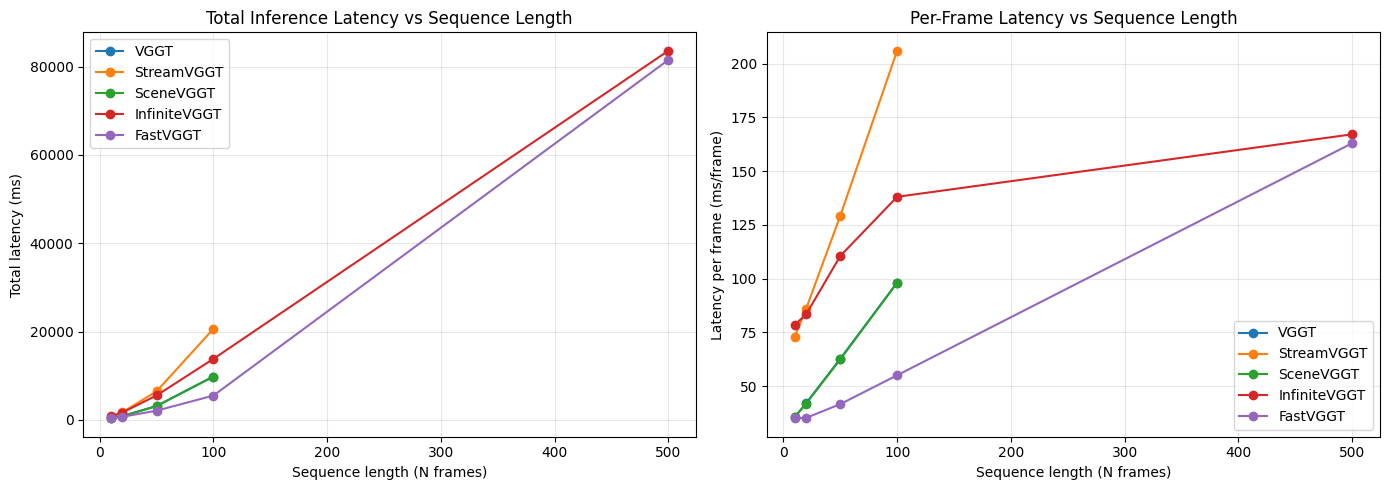

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

df_ok = df[df["status"] == "ok"]

for variant in df_ok["variant"].unique():
    sub = df_ok[df_ok["variant"] == variant].sort_values("seq_len")
    ax1.plot(sub["seq_len"], sub["latency_ms"], marker="o", label=variant)
    ax2.plot(sub["seq_len"], sub["latency_per_frame_ms"], marker="o", label=variant)

ax1.set_xlabel("Sequence length (N frames)")
ax1.set_ylabel("Total latency (ms)")
ax1.set_title("Total Inference Latency vs Sequence Length")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel("Sequence length (N frames)")
ax2.set_ylabel("Latency per frame (ms/frame)")
ax2.set_title("Per-Frame Latency vs Sequence Length")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 9. Memory Plot <a id='9'></a>

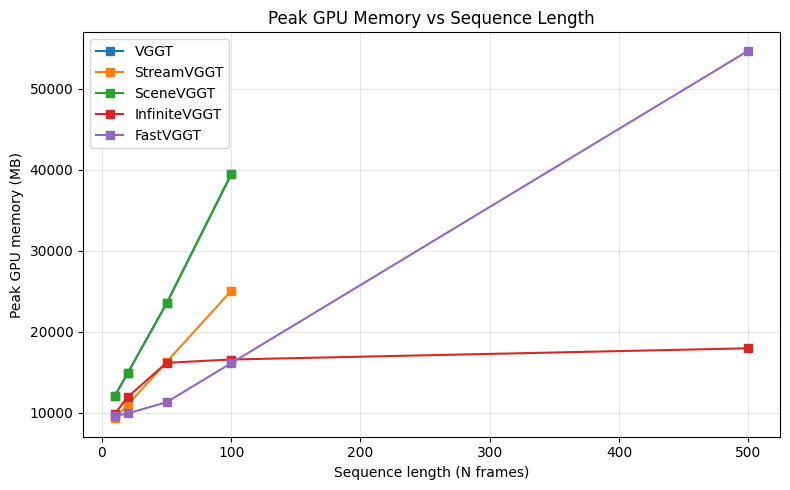

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

for variant in df_ok["variant"].unique():
    sub = df_ok[df_ok["variant"] == variant].sort_values("seq_len")
    ax.plot(sub["seq_len"], sub["peak_memory_mb"], marker="s", label=variant)

ax.set_xlabel("Sequence length (N frames)")
ax.set_ylabel("Peak GPU memory (MB)")
ax.set_title("Peak GPU Memory vs Sequence Length")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 10. Combined Summary Bar Chart <a id='10'></a>

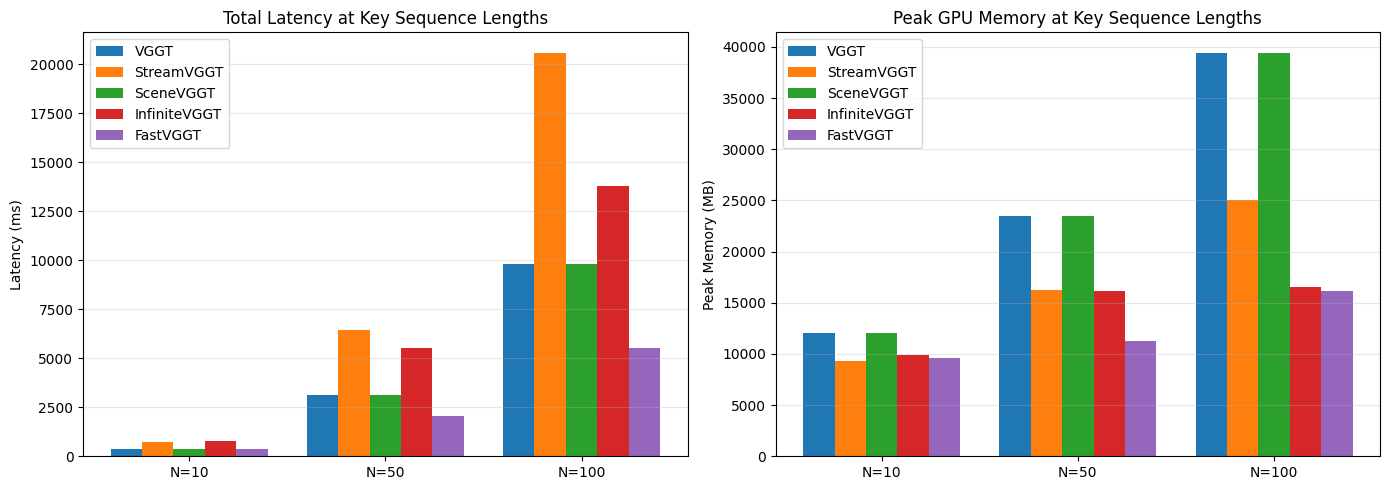

In [11]:
key_ns = [10, 50, 100]
df_key = df_ok[df_ok["seq_len"].isin(key_ns)].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

variants = df_key["variant"].unique()
n_variants = len(variants)
bar_width = 0.8 / n_variants
x_positions = np.arange(len(key_ns))

for i, variant in enumerate(variants):
    sub = df_key[df_key["variant"] == variant].set_index("seq_len")
    latencies = [sub.loc[n, "latency_ms"] if n in sub.index else 0 for n in key_ns]
    memories = [sub.loc[n, "peak_memory_mb"] if n in sub.index else 0 for n in key_ns]
    offset = (i - n_variants / 2 + 0.5) * bar_width
    axes[0].bar(x_positions + offset, latencies, bar_width, label=variant)
    axes[1].bar(x_positions + offset, memories, bar_width, label=variant)

for ax, ylabel, title in [
    (axes[0], "Latency (ms)", "Total Latency at Key Sequence Lengths"),
    (axes[1], "Peak Memory (MB)", "Peak GPU Memory at Key Sequence Lengths"),
]:
    ax.set_xticks(x_positions)
    ax.set_xticklabels([f"N={n}" for n in key_ns])
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

---
## 11. Output Shape Consistency <a id='11'></a>

Compare output shapes across all variants at N=10 to check compatibility
for downstream world model integration.

In [12]:
# Gather output shapes at N=10
df_n10 = df[df["seq_len"] == 10].copy()

print("Output shapes at N=10:\n")
for _, row in df_n10.iterrows():
    print(f"--- {row['variant']} (status: {row['status']}) ---")
    if row["output_shapes"]:
        for key, shape in row["output_shapes"].items():
            print(f"  {key:<25} {shape}")
    else:
        print("  (no output shapes available)")
    print()

# Build comparison table for common keys
shape_records = []
for _, row in df_n10.iterrows():
    if row["output_shapes"]:
        for key, shape in row["output_shapes"].items():
            shape_records.append({
                "variant": row["variant"],
                "output_key": key,
                "shape": str(shape),
            })

if shape_records:
    df_shapes = pd.DataFrame(shape_records)
    shape_pivot = df_shapes.pivot(index="output_key", columns="variant", values="shape")
    print("\nShape comparison pivot table:")
    display(shape_pivot)

    # Flag mismatches
    print("\nMismatch check:")
    for key in shape_pivot.index:
        unique_shapes = shape_pivot.loc[key].dropna().unique()
        if len(unique_shapes) > 1:
            print(f"  WARNING: '{key}' has different shapes: {unique_shapes}")
        else:
            print(f"  OK: '{key}' consistent across all variants")

Output shapes at N=10:

--- VGGT (status: ok) ---
  pose_enc                  (1, 10, 9)
  pose_enc_list             list[4] of (1, 10, 9)
  depth                     (1, 10, 518, 518, 1)
  depth_conf                (1, 10, 518, 518)
  world_points              (1, 10, 518, 518, 3)
  world_points_conf         (1, 10, 518, 518)
  images                    (1, 10, 3, 518, 518)

--- StreamVGGT (status: ok) ---
  pts3d_in_other_view       (10, 1, 518, 518, 3)
  conf                      (10, 1, 518, 518)
  depth                     (10, 1, 518, 518, 1)
  depth_conf                (10, 1, 518, 518)
  camera_pose               (10, 1, 9)

--- SceneVGGT (status: ok) ---
  pose_enc                  (1, 10, 9)
  depth                     (1, 10, 518, 518, 1)
  depth_conf                (1, 10, 518, 518)
  world_points              (1, 10, 518, 518, 3)
  world_points_conf         (1, 10, 518, 518)
  images                    (1, 10, 3, 518, 518)

--- InfiniteVGGT (status: ok) ---
  pts3d_in_othe

variant,FastVGGT,InfiniteVGGT,SceneVGGT,StreamVGGT,VGGT
output_key,,,,,
camera_pose,NaN,"(10, 1, 9)",NaN,"(10, 1, 9)",NaN
conf,NaN,"(10, 1, 518, 518)",NaN,"(10, 1, 518, 518)",NaN
depth,"(1, 10, 518, 518, 1)","(10, 1, 518, 518, 1)","(1, 10, 518, 518, 1)","(10, 1, 518, 518, 1)","(1, 10, 518, 518, 1)"
depth_conf,"(1, 10, 518, 518)","(10, 1, 518, 518)","(1, 10, 518, 518)","(10, 1, 518, 518)","(1, 10, 518, 518)"
images,"(1, 10, 3, 518, 518)",NaN,"(1, 10, 3, 518, 518)",NaN,"(1, 10, 3, 518, 518)"
pose_enc,"(1, 10, 9)",NaN,"(1, 10, 9)",NaN,"(1, 10, 9)"
pose_enc_list,"list[4] of (1, 10, 9)",NaN,NaN,NaN,"list[4] of (1, 10, 9)"
pts3d_in_other_view,NaN,"(10, 1, 518, 518, 3)",NaN,"(10, 1, 518, 518, 3)",NaN
world_points,NaN,NaN,"(1, 10, 518, 518, 3)",NaN,"(1, 10, 518, 518, 3)"



Mismatch check:
  OK: 'camera_pose' consistent across all variants
  OK: 'conf' consistent across all variants
  OK: 'images' consistent across all variants
  OK: 'pose_enc' consistent across all variants
  OK: 'pose_enc_list' consistent across all variants
  OK: 'pts3d_in_other_view' consistent across all variants
  OK: 'world_points' consistent across all variants
  OK: 'world_points_conf' consistent across all variants


---
## 12. Summary & Recommendation <a id='12'></a>

### Trade-off Analysis

| Criterion | Best candidate | Notes |
|-----------|---------------|-------|
| **Lowest latency** | FastVGGT | Token merging reduces computation |
| **Lowest memory** | StreamVGGT / InfiniteVGGT | Streaming processes frames incrementally |
| **Long sequences** | InfiniteVGGT | Token budget prevents OOM on N>100 |
| **Output compatibility** | VGGT / SceneVGGT / FastVGGT | Same output dict format |
| **Scene understanding** | SceneVGGT | Built-in SLAM modules, but adds complexity |

### Recommendation

**Fill in after running on GPU:** Compare the actual numbers from the benchmark above.
Key questions:
1. Which variants can handle N=100+ without OOM on H100 80GB?
2. What is the per-frame latency overhead of streaming vs batch?
3. Are output shapes compatible with DreamerV3 observation encoder?

The selected variant will be integrated as the 3D feature encoder in the
DreamerV3 world model pipeline for HM3D ObjectNav experiments.

---
## 13. DreamerV3 Integration Benchmark <a id='13'></a>

Simulates the real thesis use case: **DreamerV3 with a VGGT 3D encoder**.

**Scenario:** 16 parallel environments, each producing 1 frame per step.
Each RL step adds 16 new frames to the accumulated sequence.

**Processing modes:**
- **Batch models** (VGGT, SceneVGGT, FastVGGT): must re-process the entire growing sequence each step
- **Streaming models** (StreamVGGT, InfiniteVGGT): only process the 16 new frames each step (KV cache retains history)

**Criteria:**
| Metric | Why it matters |
|--------|---------------|
| Step latency (ms) | Must keep up with RL loop (target: <500ms/step) |
| Peak GPU memory (MB) | Must leave room for DreamerV3 world model + policy (~4–8 GB) |
| Throughput (frames/sec) | DreamerV3 typically steps at 10–30 FPS |
| Memory growth rate | Linear vs quadratic determines max episode length |

**Test plan:** 20 steps (sequence grows from 16 to 320 frames).

In [13]:
BATCH_SIZE = 16   # parallel environments
N_STEPS = 20      # RL steps to simulate (sequence: 16 -> 320 frames)

def benchmark_dreamer_integration(
    variant_name: str,
    model,
    inference_fn,
    all_images: torch.Tensor,
    batch_size: int = BATCH_SIZE,
    n_steps: int = N_STEPS,
    is_streaming: bool = False,
) -> list[dict]:
    """Simulate DreamerV3 incremental encoding.

    For batch models: re-process entire sequence each step.
    For streaming models: only process new frames each step.
    """
    step_results = []

    if is_streaming:
        # Streaming: feed frames one-by-one, measure each batch of new frames
        for step in range(n_steps):
            start_idx = step * batch_size
            end_idx = start_idx + batch_size
            new_frames = all_images[start_idx:end_idx].to(device=device, dtype=dtype)
            frames = [{"img": new_frames[i].unsqueeze(0)} for i in range(batch_size)]

            reset_memory_stats()
            if device.type == "cuda":
                torch.cuda.synchronize()

            t0 = time.perf_counter()
            with torch.no_grad():
                with torch.amp.autocast(device.type, dtype=dtype):
                    for frame in frames:
                        model.inference([frame])
            if device.type == "cuda":
                torch.cuda.synchronize()
            t1 = time.perf_counter()

            step_results.append({
                "variant": variant_name,
                "step": step,
                "total_frames": end_idx,
                "step_latency_ms": (t1 - t0) * 1000,
                "peak_memory_mb": get_peak_memory_mb(),
                "fps": batch_size / (t1 - t0),
            })
            print(f"    step {step:2d} | frames={end_idx:3d} | "
                  f"latency={step_results[-1]['step_latency_ms']:.0f}ms | "
                  f"mem={step_results[-1]['peak_memory_mb']:.0f}MB | "
                  f"fps={step_results[-1]['fps']:.1f}")
    else:
        # Batch: re-process entire accumulated sequence each step
        for step in range(n_steps):
            end_idx = (step + 1) * batch_size
            accumulated = all_images[:end_idx].to(device)

            reset_memory_stats()
            if device.type == "cuda":
                torch.cuda.synchronize()

            t0 = time.perf_counter()
            try:
                with torch.no_grad():
                    with torch.amp.autocast(device.type, dtype=dtype):
                        output = inference_fn(model, accumulated)
                if device.type == "cuda":
                    torch.cuda.synchronize()
                t1 = time.perf_counter()

                step_results.append({
                    "variant": variant_name,
                    "step": step,
                    "total_frames": end_idx,
                    "step_latency_ms": (t1 - t0) * 1000,
                    "peak_memory_mb": get_peak_memory_mb(),
                    "fps": batch_size / (t1 - t0),
                })
                print(f"    step {step:2d} | frames={end_idx:3d} | "
                      f"latency={step_results[-1]['step_latency_ms']:.0f}ms | "
                      f"mem={step_results[-1]['peak_memory_mb']:.0f}MB | "
                      f"fps={step_results[-1]['fps']:.1f}")
            except torch.OutOfMemoryError:
                t1 = time.perf_counter()
                print(f"    step {step:2d} | frames={end_idx:3d} | OOM")
                step_results.append({
                    "variant": variant_name,
                    "step": step,
                    "total_frames": end_idx,
                    "step_latency_ms": float("nan"),
                    "peak_memory_mb": float("nan"),
                    "fps": float("nan"),
                })
                break  # stop after OOM
            finally:
                del accumulated
                if device.type == "cuda":
                    torch.cuda.empty_cache()

    return step_results

print(f"Benchmark config: batch_size={BATCH_SIZE}, n_steps={N_STEPS}, "
      f"max_frames={BATCH_SIZE * N_STEPS}")

Benchmark config: batch_size=16, n_steps=20, max_frames=320


In [14]:
STREAMING_VARIANTS = {"StreamVGGT", "InfiniteVGGT"}
# Skip FastVGGT if it errored in the main benchmark
SKIP_VARIANTS = {v for v in df[df["status"].str.startswith("error", na=False)]["variant"].unique()}
print(f"Skipping variants with errors: {SKIP_VARIANTS}")

dreamer_results = []

for variant_name in LOADERS:
    if variant_name in SKIP_VARIANTS:
        print(f"\nSkipping {variant_name} (errored in main benchmark)")
        continue

    print(f"\n{'='*60}")
    print(f"DreamerV3 benchmark: {variant_name}")
    print(f"{'='*60}")

    try:
        model = LOADERS[variant_name]()
    except Exception as e:
        print(f"  FAILED to load: {e}")
        continue

    is_streaming = variant_name in STREAMING_VARIANTS
    inference_fn = INFERENCE_FNS[variant_name]

    results = benchmark_dreamer_integration(
        variant_name=variant_name,
        model=model,
        inference_fn=inference_fn,
        all_images=all_images,
        is_streaming=is_streaming,
    )
    dreamer_results.extend(results)
    unload_model(model)

df_dreamer = pd.DataFrame(dreamer_results)
print(f"\nTotal results: {len(df_dreamer)}")
display(df_dreamer.round(1))

Skipping variants with errors: set()

DreamerV3 benchmark: VGGT


/pfs/data6/home/ul/ul_student/ul_hfj15/Master-Thesis-3D-VLA/external/VGGT/vggt/models/vggt.py:65: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


    step  0 | frames= 16 | latency=778ms | mem=13680MB | fps=20.6


    step  1 | frames= 32 | latency=1606ms | mem=18320MB | fps=10.0


    step  2 | frames= 48 | latency=2942ms | mem=22959MB | fps=5.4


...

    step 17 | frames=288 | latency=30672ms | mem=35102MB | fps=0.5


    step 18 | frames=304 | latency=33640ms | mem=36700MB | fps=0.5


    step 19 | frames=320 | latency=36695ms | mem=38295MB | fps=0.4



Total results: 96


,variant,step,total_frames,step_latency_ms,peak_memory_mb,fps
0,VGGT,0,16,777.7,13680.2,20.6
1,VGGT,1,32,1605.5,18320.5,10.0
2,VGGT,2,48,2942.1,22958.7,5.4
3,VGGT,3,64,4626.6,27785.5,3.5
4,VGGT,4,80,6695.6,33025.2,2.4
...,...,...,...,...,...,...
91,FastVGGT,15,256,24954.6,31908.6,0.6
92,FastVGGT,16,272,27762.9,33505.4,0.6
93,FastVGGT,17,288,30672.3,35102.5,0.5
94,FastVGGT,18,304,33639.7,36700.2,0.5


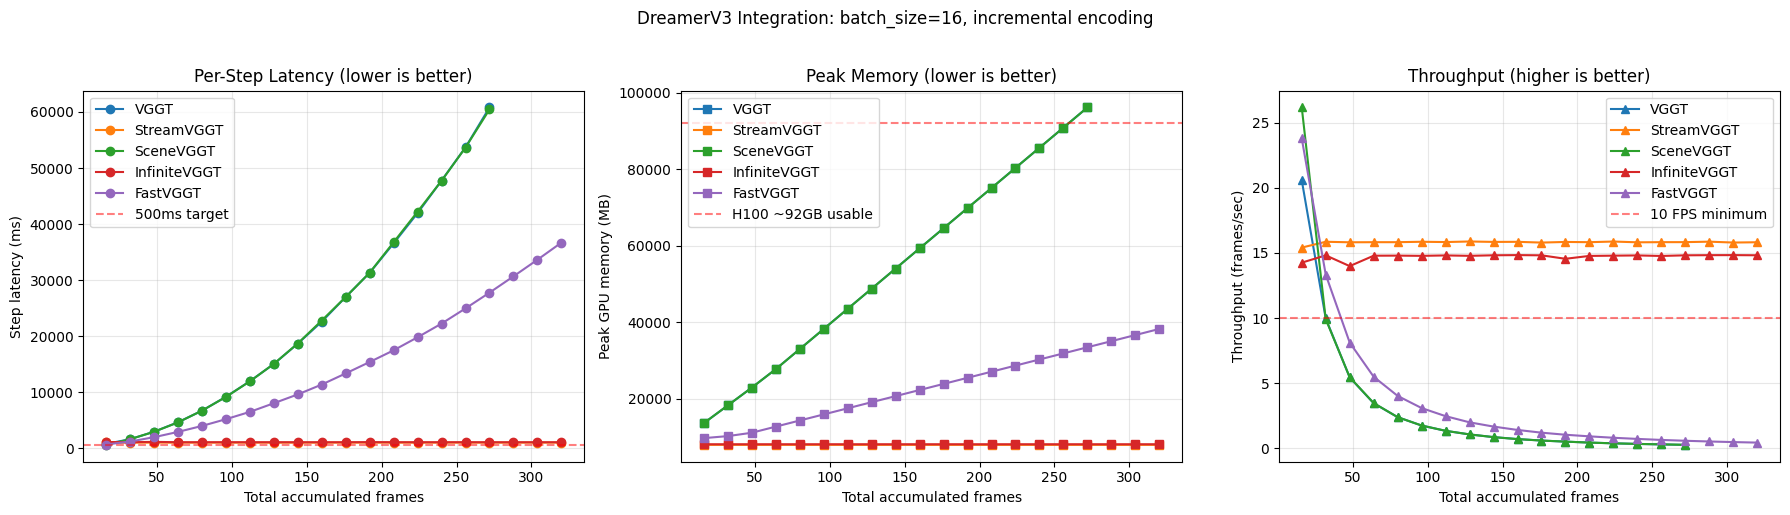

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for variant in df_dreamer["variant"].unique():
    sub = df_dreamer[df_dreamer["variant"] == variant].dropna()
    axes[0].plot(sub["total_frames"], sub["step_latency_ms"], marker="o", label=variant)
    axes[1].plot(sub["total_frames"], sub["peak_memory_mb"], marker="s", label=variant)
    axes[2].plot(sub["total_frames"], sub["fps"], marker="^", label=variant)

# Step latency
axes[0].axhline(y=500, color="red", linestyle="--", alpha=0.5, label="500ms target")
axes[0].set_xlabel("Total accumulated frames")
axes[0].set_ylabel("Step latency (ms)")
axes[0].set_title("Per-Step Latency (lower is better)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Peak memory
axes[1].axhline(y=92_000, color="red", linestyle="--", alpha=0.5, label="H100 ~92GB usable")
axes[1].set_xlabel("Total accumulated frames")
axes[1].set_ylabel("Peak GPU memory (MB)")
axes[1].set_title("Peak Memory (lower is better)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Throughput
axes[2].axhline(y=10, color="red", linestyle="--", alpha=0.5, label="10 FPS minimum")
axes[2].set_xlabel("Total accumulated frames")
axes[2].set_ylabel("Throughput (frames/sec)")
axes[2].set_title("Throughput (higher is better)")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle(f"DreamerV3 Integration: batch_size={BATCH_SIZE}, incremental encoding", y=1.02)
plt.tight_layout()
plt.show()

---
## 14. 3D Representations Visualization — All Variants <a id='14'></a>

Runs **all working VGGT variants** on 100 Habitat frames and visualizes:
1. **Depth maps** — side-by-side per variant
2. **Interactive 3D point clouds** (plotly) — rotate, pan, zoom to explore each variant's 3D output
3. **Side-by-side frame-colored point clouds** — reveals coordinate frame differences

**Output keys by variant:**
| Variant | 3D Points Key | Coordinate Frame |
|---------|--------------|-----------------|
| VGGT | `world_points` | Shared pseudo-world |
| SceneVGGT | `world_points` | Shared pseudo-world |
| StreamVGGT | `pts3d_in_other_view` | Reference camera |
| InfiniteVGGT | `pts3d_in_other_view` | Reference camera |
| FastVGGT | `world_points` | Shared pseudo-world (if working) |

In [16]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

N_VIS = 100
vis_images = all_images[:N_VIS].to(device)
rgb_frames = vis_images.cpu()  # [100, 3, H, W]

# Map variant -> which output key holds 3D points, and axis layout
VARIANT_3D_CONFIG = {
    "VGGT":          {"key": "world_points",        "axes": "batch_first"},  # [1, S, H, W, 3]
    "StreamVGGT":    {"key": "pts3d_in_other_view", "axes": "seq_first"},    # [S, 1, H, W, 3]
    "SceneVGGT":     {"key": "world_points",        "axes": "batch_first"},
    "InfiniteVGGT":  {"key": "pts3d_in_other_view", "axes": "seq_first"},
    "FastVGGT":      {"key": "world_points",        "axes": "batch_first"},
}

# Skip variants that errored in the main benchmark
skip = {v for v in df[df["status"].str.startswith("error", na=False)]["variant"].unique()}
print(f"Skipping (errored): {skip}")

# Collect outputs for each variant
variant_data = {}  # name -> {"pts3d": [S,H,W,3], "depth": [S,H,W,1], "depth_conf": [S,H,W]}

for name in LOADERS:
    if name in skip:
        print(f"\nSkipping {name}")
        continue
    
    cfg = VARIANT_3D_CONFIG[name]
    print(f"\n{'='*50}")
    print(f"Running {name} on {N_VIS} frames...")
    
    try:
        model = LOADERS[name]()
        with torch.no_grad():
            with torch.amp.autocast(device.type, dtype=dtype):
                out = INFERENCE_FNS[name](model, vis_images)
        
        # Extract 3D points -> [S, H, W, 3]
        pts_key = cfg["key"]
        if pts_key in out:
            raw = out[pts_key].cpu().float()
            if cfg["axes"] == "batch_first":
                pts3d = raw[0]        # [1, S, H, W, 3] -> [S, H, W, 3]
            else:
                pts3d = raw[:, 0]     # [S, 1, H, W, 3] -> [S, H, W, 3]
        else:
            print(f"  WARNING: key '{pts_key}' not found. Keys: {list(out.keys())}")
            pts3d = None
        
        # Extract depth -> [S, H, W, 1]
        if "depth" in out:
            raw_d = out["depth"].cpu().float()
            depth = raw_d[0] if cfg["axes"] == "batch_first" else raw_d[:, 0]
        else:
            depth = None
        
        # Extract depth_conf -> [S, H, W]
        if "depth_conf" in out:
            raw_c = out["depth_conf"].cpu().float()
            conf = raw_c[0] if cfg["axes"] == "batch_first" else raw_c[:, 0]
        else:
            conf = None
        
        variant_data[name] = {"pts3d": pts3d, "depth": depth, "depth_conf": conf}
        print(f"  pts3d: {pts3d.shape if pts3d is not None else 'N/A'}")
        print(f"  depth: {depth.shape if depth is not None else 'N/A'}")
        
        unload_model(model)
    except Exception as e:
        print(f"  FAILED: {e}")
        continue

del vis_images
torch.cuda.empty_cache()
print(f"\nCollected data for: {list(variant_data.keys())}")

Skipping (errored): set()

Running VGGT on 100 frames...


/pfs/data6/home/ul/ul_student/ul_hfj15/Master-Thesis-3D-VLA/external/VGGT/vggt/models/vggt.py:65: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


  pts3d: torch.Size([100, 518, 518, 3])
  depth: torch.Size([100, 518, 518, 1])

Running StreamVGGT on 100 frames...


/pfs/data6/home/ul/ul_student/ul_hfj15/Master-Thesis-3D-VLA/external/StreamVGGT/src/streamvggt/models/streamvggt.py:126: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


  pts3d: torch.Size([100, 518, 518, 3])
  depth: torch.Size([100, 518, 518, 1])

Running SceneVGGT on 100 frames...


...

  pts3d: torch.Size([100, 518, 518, 3])
  depth: torch.Size([100, 518, 518, 1])

Running InfiniteVGGT on 100 frames...


/pfs/data6/home/ul/ul_student/ul_hfj15/Master-Thesis-3D-VLA/external/InfiniteVGGT/src/streamvggt/models/streamvggt.py:139: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


  pts3d: torch.Size([100, 518, 518, 3])
  depth: torch.Size([100, 518, 518, 1])

Running FastVGGT on 100 frames...


  pts3d: N/A
  depth: torch.Size([100, 518, 518, 1])



Collected data for: ['VGGT', 'StreamVGGT', 'SceneVGGT', 'InfiniteVGGT', 'FastVGGT']


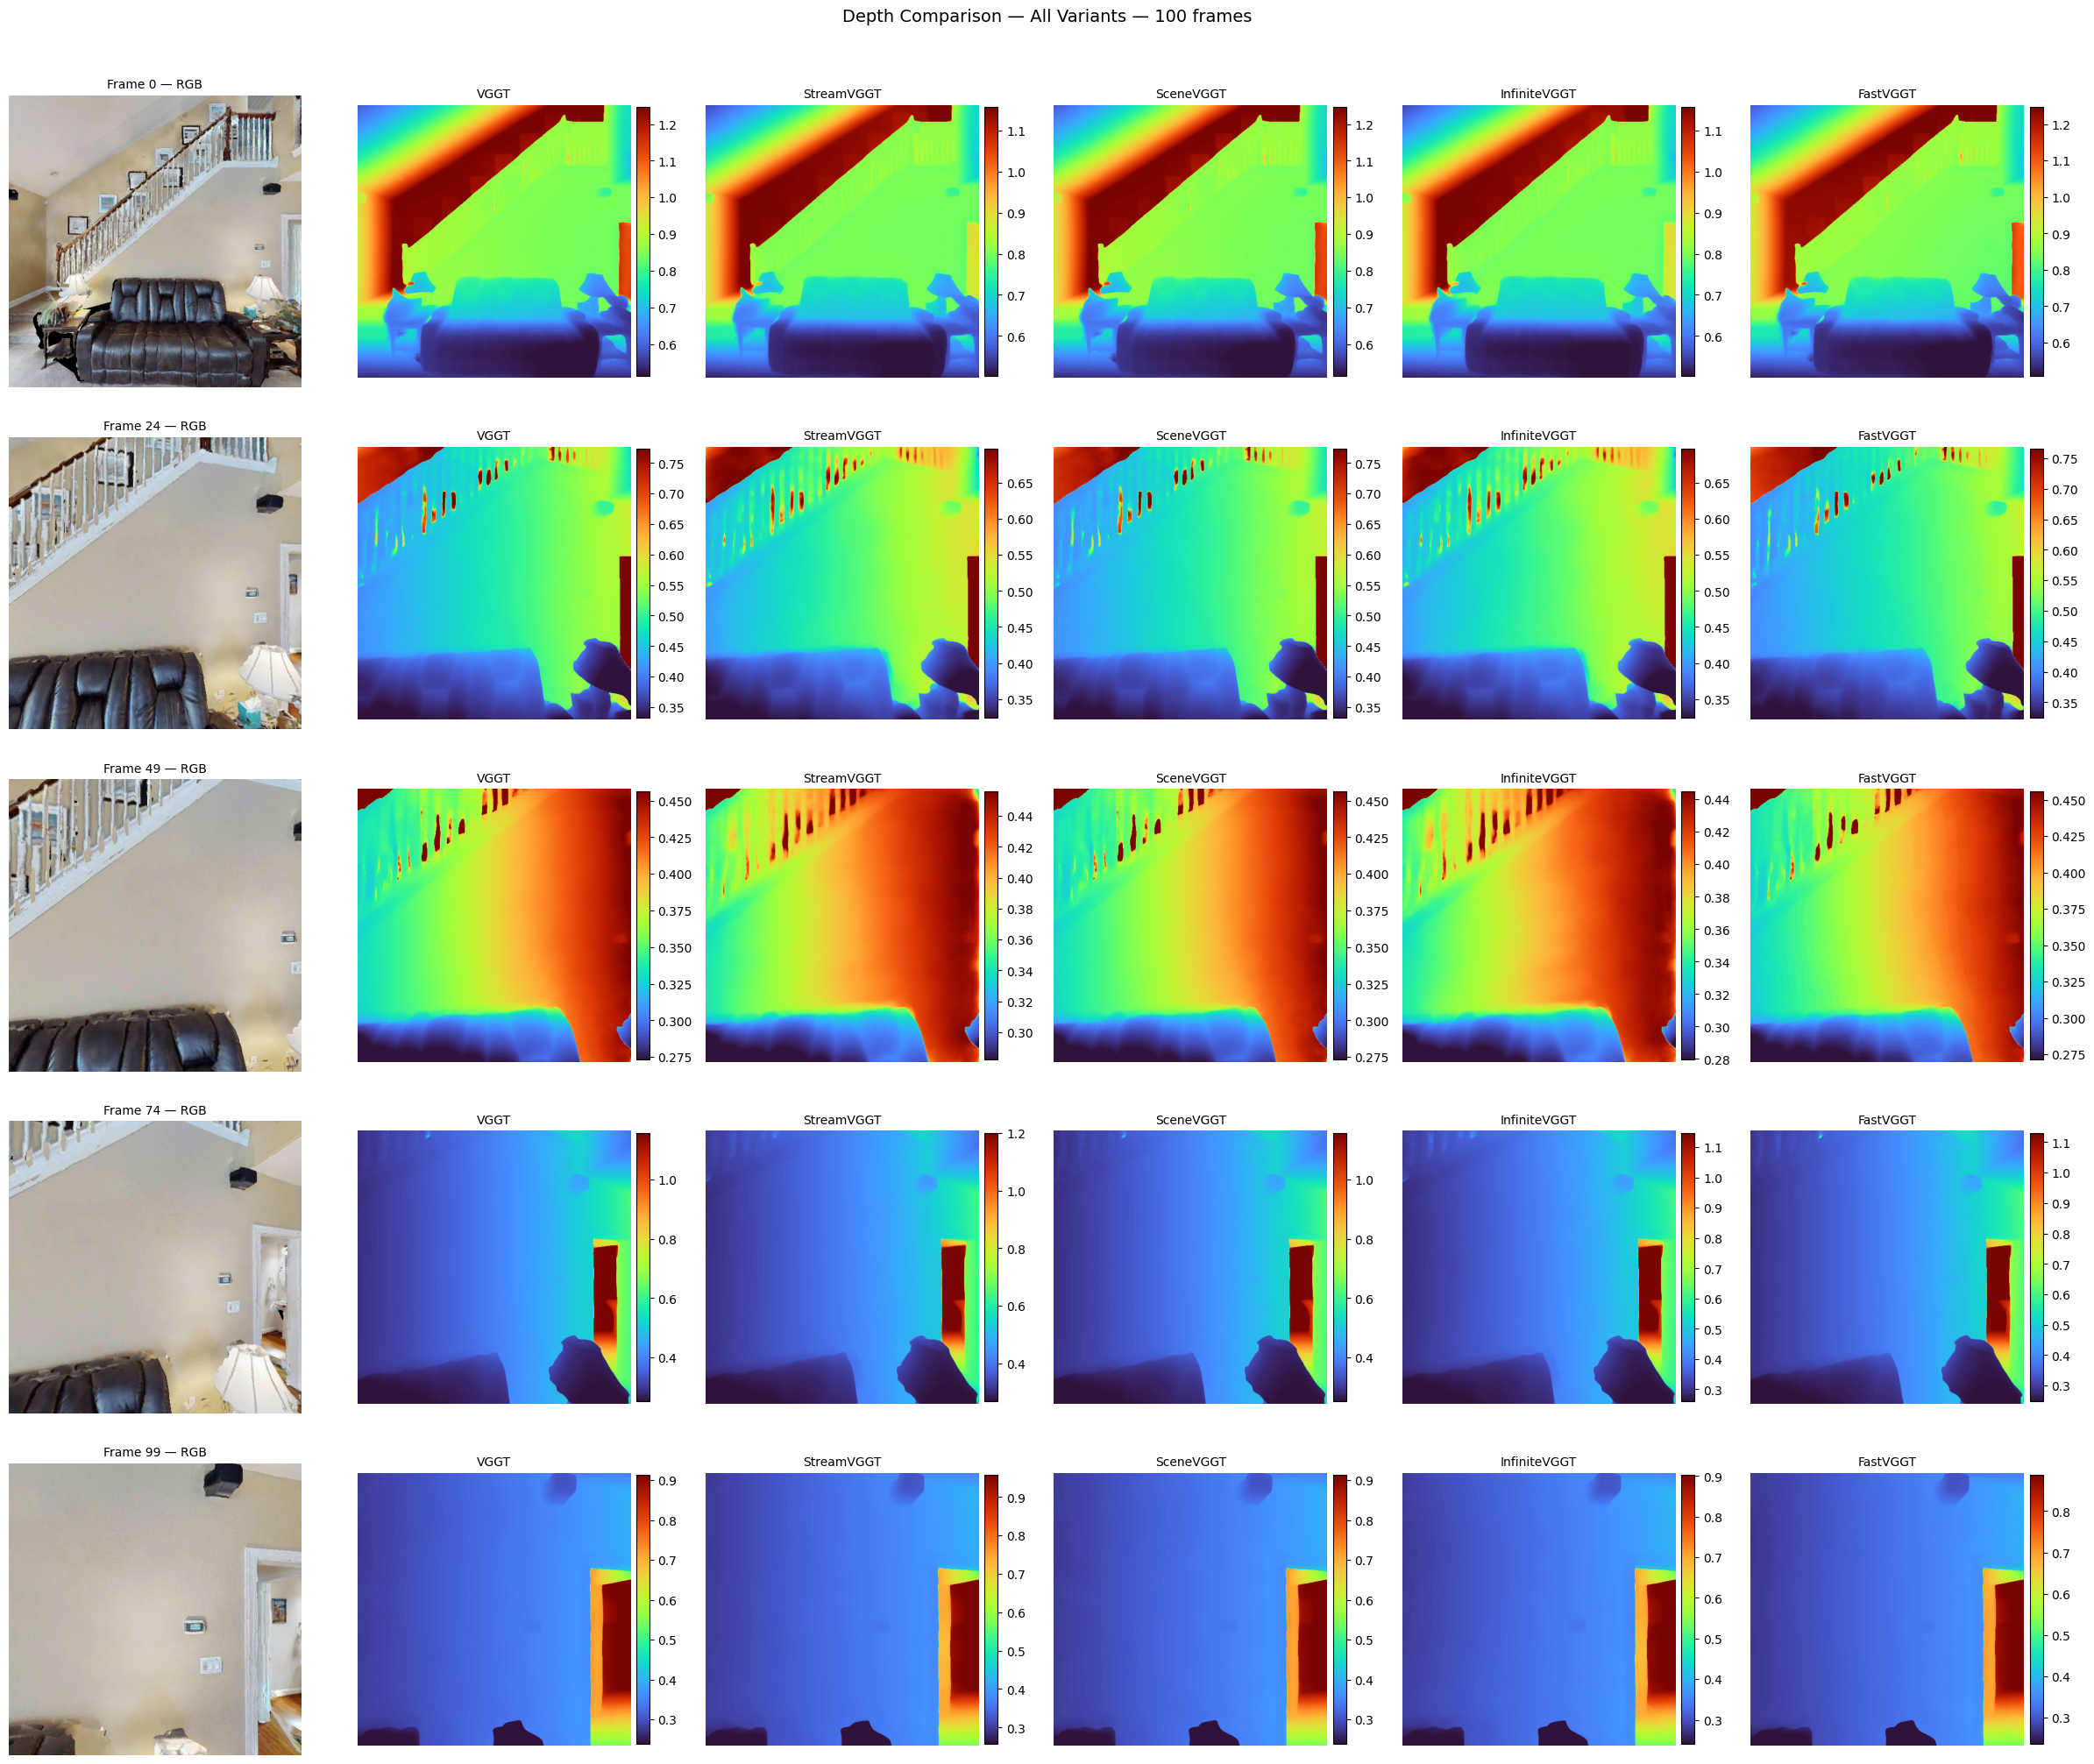

In [17]:
# --- Depth maps: all variants side-by-side ---
SHOW_FRAMES = [0, 24, 49, 74, 99]
variants_with_depth = [v for v in variant_data if variant_data[v]["depth"] is not None]
n_variants = len(variants_with_depth)

fig, axes = plt.subplots(len(SHOW_FRAMES), n_variants + 1,
                         figsize=(4 * (n_variants + 1), 4 * len(SHOW_FRAMES)))

for row, fi in enumerate(SHOW_FRAMES):
    # RGB
    rgb = rgb_frames[fi].permute(1, 2, 0).numpy()
    axes[row, 0].imshow(rgb)
    axes[row, 0].set_title(f"Frame {fi} — RGB", fontsize=10)
    axes[row, 0].axis("off")
    
    # Depth per variant
    for col, vname in enumerate(variants_with_depth, 1):
        d = variant_data[vname]["depth"][fi, :, :, 0].numpy()
        valid = d[np.isfinite(d)]
        vmin, vmax = np.percentile(valid, 2), np.percentile(valid, 98)
        im = axes[row, col].imshow(d, cmap="turbo", vmin=vmin, vmax=vmax)
        axes[row, col].set_title(f"{vname}", fontsize=10)
        axes[row, col].axis("off")
        plt.colorbar(im, ax=axes[row, col], fraction=0.046, pad=0.02)

plt.suptitle(f"Depth Comparison — All Variants — {N_VIS} frames", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [18]:
# --- Build point clouds for all variants ---
import plotly.graph_objects as go
from plotly.subplots import make_subplots

PIXEL_STEP = 8   # denser for saved files
FRAME_STEP = 2   # every 2nd frame
selected_frames = list(range(0, N_VIS, FRAME_STEP))

OUT_DIR = Path("..") / "outputs" / "3d_pointclouds"
OUT_DIR.mkdir(parents=True, exist_ok=True)

def build_pointcloud(points_3d, rgb_all, frame_indices, pixel_step):
    xs, ys, zs, colors, frame_ids = [], [], [], [], []
    for fi in frame_indices:
        pts = points_3d[fi, ::pixel_step, ::pixel_step].reshape(-1, 3).numpy()
        rgb = rgb_all[fi].permute(1, 2, 0)[::pixel_step, ::pixel_step].reshape(-1, 3).numpy()
        mask = np.isfinite(pts).all(axis=1)
        pts, rgb = pts[mask], rgb[mask]
        xs.append(pts[:, 0]); ys.append(pts[:, 1]); zs.append(pts[:, 2])
        colors.append(rgb); frame_ids.append(np.full(len(pts), fi))
    return (np.concatenate(xs), np.concatenate(ys), np.concatenate(zs),
            np.concatenate(colors), np.concatenate(frame_ids))

def rgb_to_plotly(rgb):
    rgb_uint8 = (np.clip(rgb, 0, 1) * 255).astype(np.uint8)
    return [f"rgb({r},{g},{b})" for r, g, b in rgb_uint8]

def save_ply(filepath, x, y, z, rgb):
    """Save point cloud as PLY with RGB colors."""
    rgb_uint8 = (np.clip(rgb, 0, 1) * 255).astype(np.uint8)
    n = len(x)
    with open(filepath, 'w') as f:
        f.write("ply\n")
        f.write("format ascii 1.0\n")
        f.write(f"element vertex {n}\n")
        f.write("property float x\n")
        f.write("property float y\n")
        f.write("property float z\n")
        f.write("property uchar red\n")
        f.write("property uchar green\n")
        f.write("property uchar blue\n")
        f.write("end_header\n")
        for i in range(n):
            f.write(f"{x[i]:.6f} {y[i]:.6f} {z[i]:.6f} {rgb_uint8[i,0]} {rgb_uint8[i,1]} {rgb_uint8[i,2]}\n")

# Build and save for each variant
variant_clouds = {}
for vname, vdata in variant_data.items():
    if vdata["pts3d"] is None:
        continue
    x, y, z, rgb, fi = build_pointcloud(
        vdata["pts3d"], rgb_frames, selected_frames, PIXEL_STEP)
    variant_clouds[vname] = {"x": x, "y": y, "z": z, "rgb": rgb, "fi": fi}
    
    # Save PLY
    ply_path = OUT_DIR / f"{vname}_pointcloud.ply"
    save_ply(ply_path, x, y, z, rgb)
    
    # Save interactive HTML
    cfg = VARIANT_3D_CONFIG[vname]
    coord_frame = "shared world frame" if cfg["key"] == "world_points" else "reference camera frame"
    fig = go.Figure(data=[go.Scatter3d(
        x=x, y=y, z=z, mode="markers",
        marker=dict(size=1.5, color=rgb_to_plotly(rgb), opacity=0.7),
        text=[f"frame {int(f)}" for f in fi], hoverinfo="text",
    )])
    fig.update_layout(
        title=f"{vname} — {cfg['key']} ({coord_frame}) | {len(x):,} points",
        scene=dict(xaxis_title="X", yaxis_title="Y", zaxis_title="Z", aspectmode="data"),
        width=900, height=700, margin=dict(l=0, r=0, t=40, b=0),
    )
    html_path = OUT_DIR / f"{vname}_pointcloud.html"
    fig.write_html(str(html_path))
    
    print(f"{vname}: {len(x):,} points -> {ply_path} + {html_path}")

VGGT: 211,250 points -> ../outputs/3d_pointclouds/VGGT_pointcloud.ply + ../outputs/3d_pointclouds/VGGT_pointcloud.html


StreamVGGT: 211,250 points -> ../outputs/3d_pointclouds/StreamVGGT_pointcloud.ply + ../outputs/3d_pointclouds/StreamVGGT_pointcloud.html


SceneVGGT: 211,250 points -> ../outputs/3d_pointclouds/SceneVGGT_pointcloud.ply + ../outputs/3d_pointclouds/SceneVGGT_pointcloud.html


InfiniteVGGT: 211,250 points -> ../outputs/3d_pointclouds/InfiniteVGGT_pointcloud.ply + ../outputs/3d_pointclouds/InfiniteVGGT_pointcloud.html


In [19]:
# --- Save side-by-side frame-colored comparison HTML ---
n_clouds = len(variant_clouds)
fig = make_subplots(
    rows=1, cols=n_clouds,
    specs=[[{"type": "scatter3d"}] * n_clouds],
    subplot_titles=list(variant_clouds.keys()),
)

for col, (vname, cloud) in enumerate(variant_clouds.items(), 1):
    fig.add_trace(go.Scatter3d(
        x=cloud["x"], y=cloud["y"], z=cloud["z"],
        mode="markers",
        marker=dict(
            size=1.2, color=cloud["fi"], colorscale="Viridis",
            cmin=0, cmax=N_VIS, opacity=0.5,
            colorbar=dict(title="Frame", len=0.8) if col == n_clouds else None,
            showscale=(col == n_clouds),
        ),
        text=[f"frame {int(f)}" for f in cloud["fi"]],
        hoverinfo="text", name=vname,
    ), row=1, col=col)

fig.update_layout(
    title_text=f"All Variants — color = frame index | {len(selected_frames)} frames",
    width=400 * n_clouds, height=700,
    margin=dict(l=0, r=0, t=60, b=0),
)

comparison_path = OUT_DIR / "all_variants_comparison.html"
fig.write_html(str(comparison_path))
print(f"Saved comparison: {comparison_path}")

# List all saved files
print(f"\nAll saved files in {OUT_DIR}/:")
for f in sorted(OUT_DIR.iterdir()):
    size_mb = f.stat().st_size / 1e6
    print(f"  {f.name:40s} {size_mb:6.1f} MB")

Saved comparison: ../outputs/3d_pointclouds/all_variants_comparison.html

All saved files in ../outputs/3d_pointclouds/:
  InfiniteVGGT_pointcloud.html               15.1 MB
  InfiniteVGGT_pointcloud.ply                 8.3 MB
  SceneVGGT_pointcloud.html                  15.2 MB
  SceneVGGT_pointcloud.ply                    8.3 MB
  StreamVGGT_pointcloud.html                 15.1 MB
  StreamVGGT_pointcloud.ply                   8.3 MB
  VGGT_pointcloud.html                       15.2 MB
  VGGT_pointcloud.ply                         8.3 MB
  all_variants_comparison.html               31.5 MB


**3D point clouds saved to `outputs/3d_pointclouds/`.**

To view locally, sync from cluster:
```bash
./sync_outputs.sh
```
Then open the `.html` files in a browser or `.ply` files in MeshLab/CloudCompare.

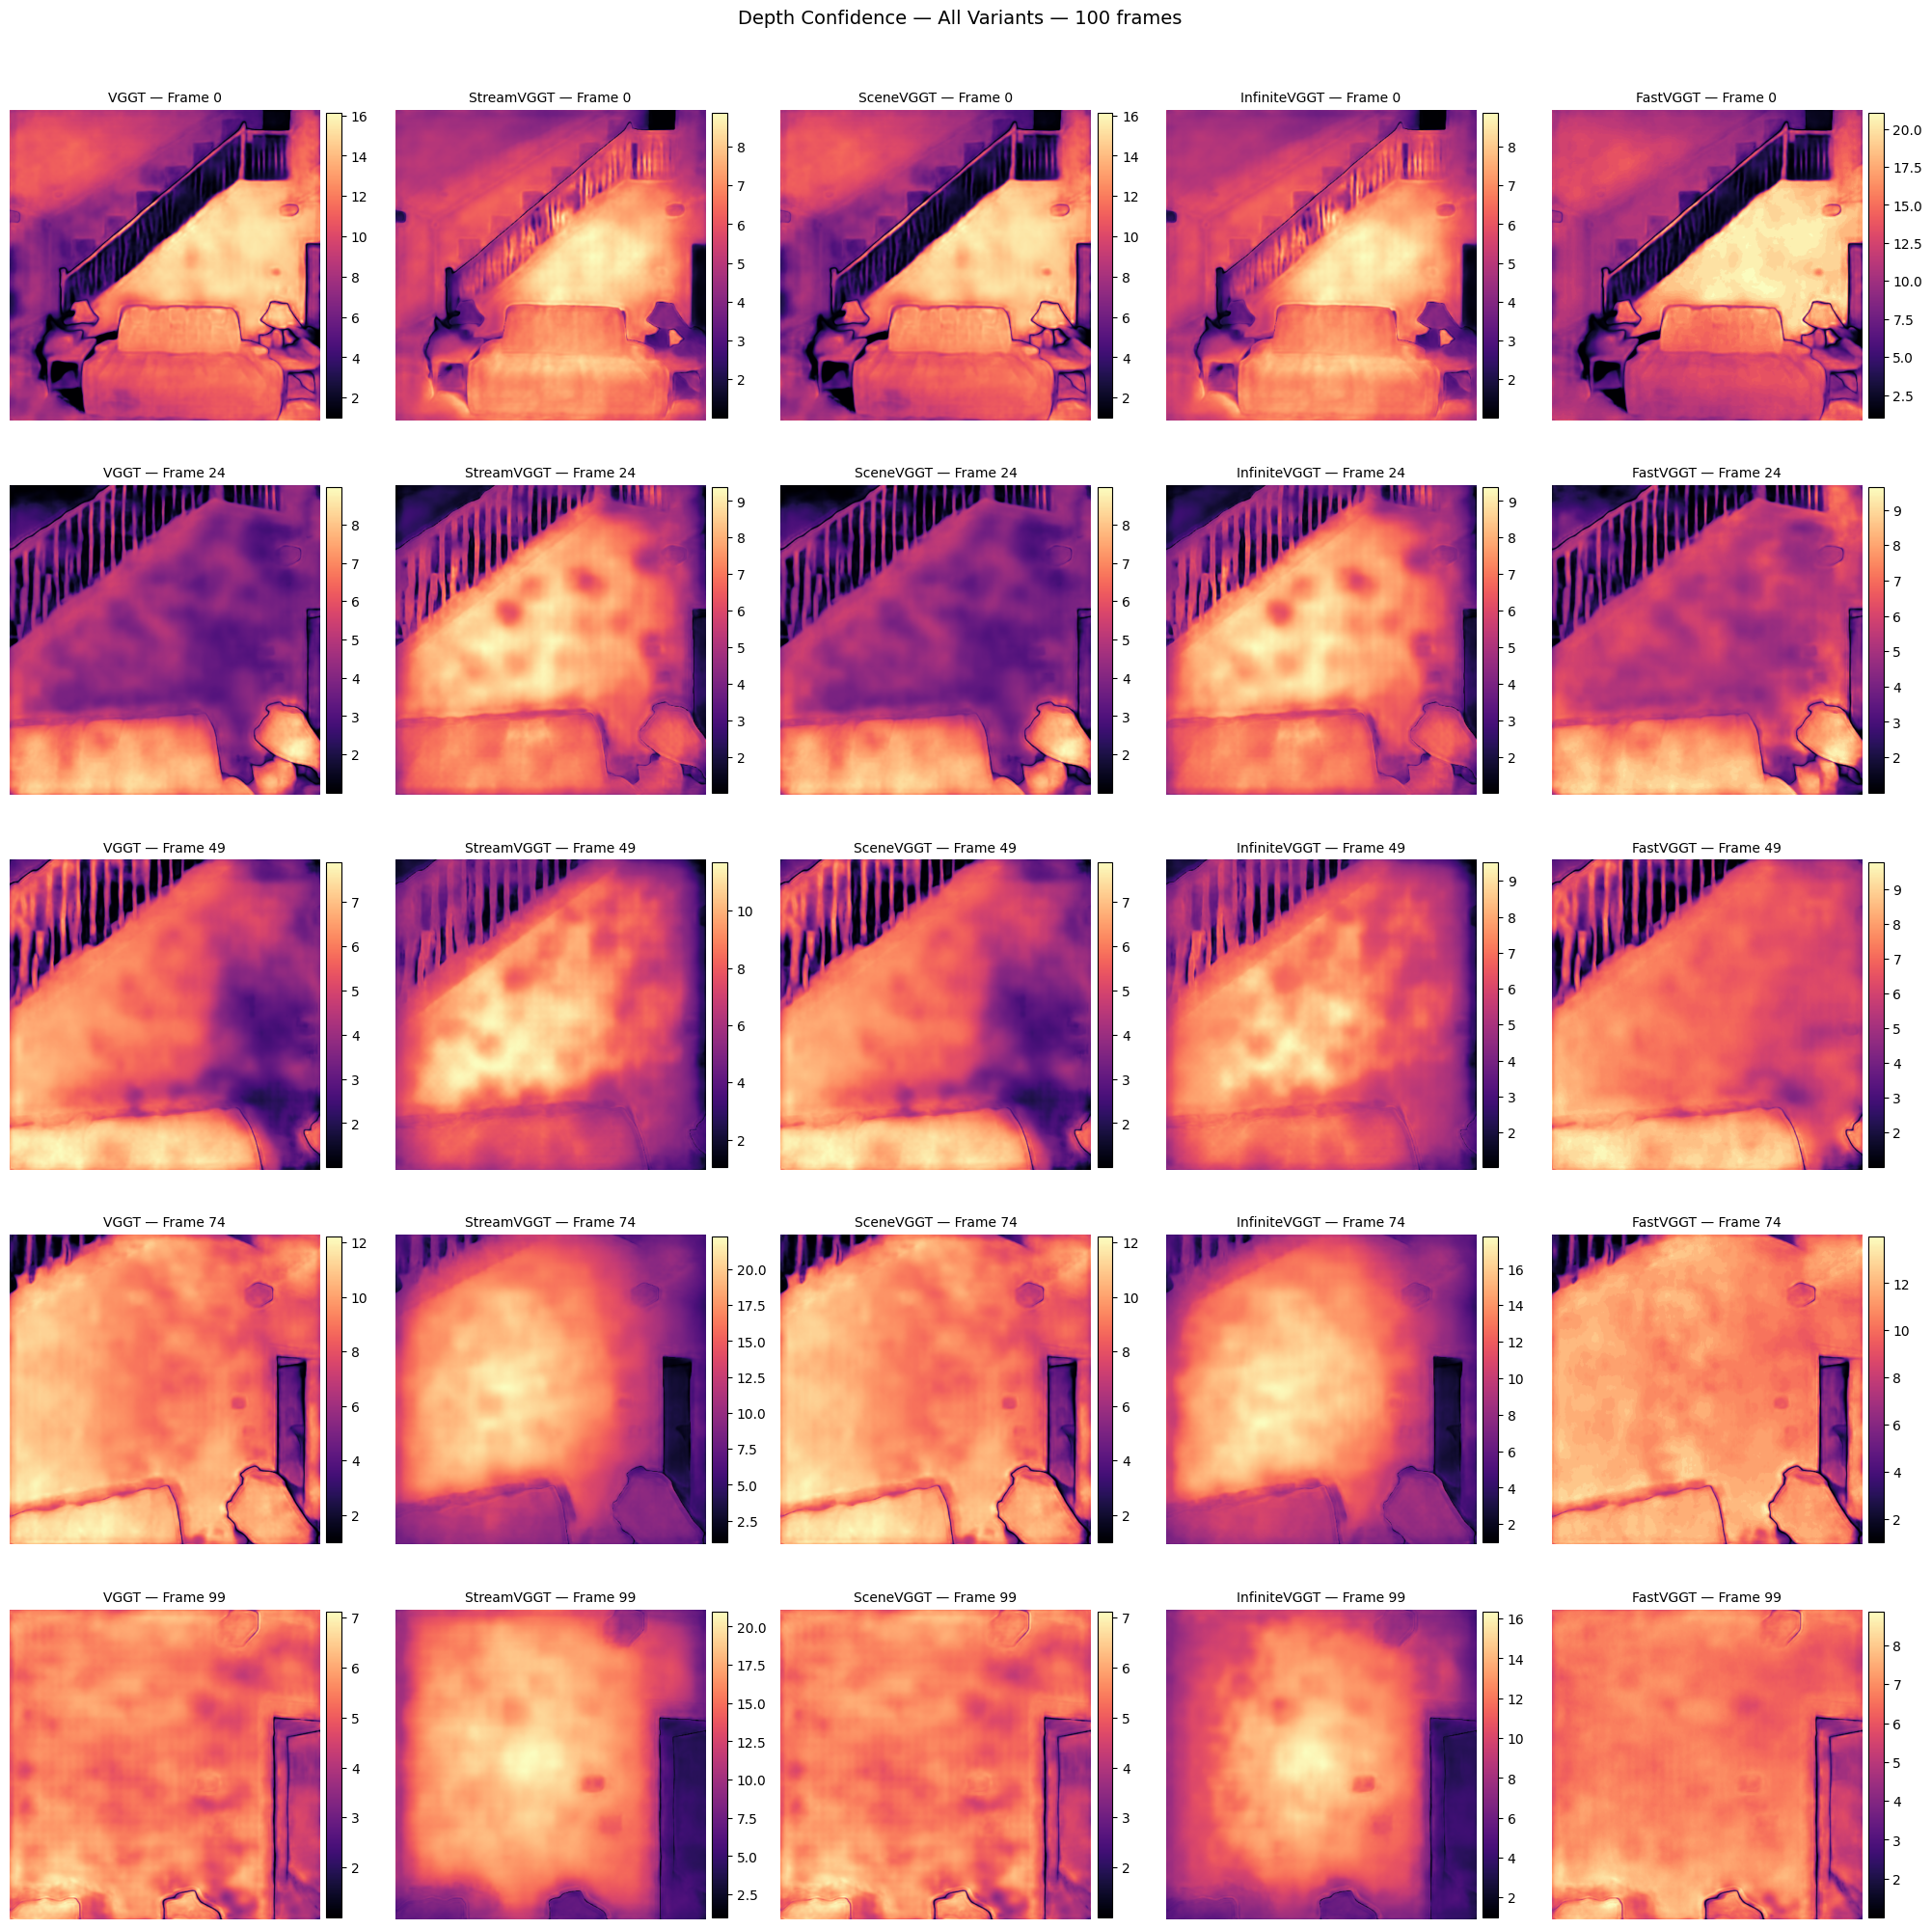

In [20]:
# --- Depth confidence: all variants ---
variants_with_conf = [v for v in variant_data if variant_data[v]["depth_conf"] is not None]
n_conf = len(variants_with_conf)

fig, axes = plt.subplots(len(SHOW_FRAMES), n_conf,
                         figsize=(4 * n_conf, 4 * len(SHOW_FRAMES)))
if n_conf == 1:
    axes = axes[:, np.newaxis]

for row, fi in enumerate(SHOW_FRAMES):
    for col, vname in enumerate(variants_with_conf):
        c = variant_data[vname]["depth_conf"][fi].numpy()
        im = axes[row, col].imshow(c, cmap="magma")
        axes[row, col].set_title(f"{vname} — Frame {fi}", fontsize=10)
        axes[row, col].axis("off")
        plt.colorbar(im, ax=axes[row, col], fraction=0.046, pad=0.02)

plt.suptitle(f"Depth Confidence — All Variants — {N_VIS} frames", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()